# Notebook 1: The Skills Landscape

**What does the German data job market actually require?**

This notebook analyzes ~2,300 data/AI job postings scraped from Bundesagentur für Arbeit in May 2026
to answer four questions:

1. What are the top skills demanded across the market?
2. How do skill requirements differ by role (Data Scientist vs Analyst vs Engineer vs ML Engineer)?
3. Which skills are "must-have" (required) vs "nice-to-have" (preferred)?
4. Which skills co-occur — what bundles do employers ask for together?

---

**Requirements:** before running, install plotting libraries:

```bash
uv add matplotlib seaborn
```

**Data source:** `data/db/jobs.duckdb` — produced by `collector.py` - `cleaner.py` - `extractor.py`.

## 1. Setup and Data Loading

In [1]:
from __future__ import annotations
import json
import re
from collections import Counter
from itertools import combinations
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
conn = duckdb.connect("~/de-data-jobs-2026/data/db/jobs.duckdb", read_only=True)

df = conn.execute("""
    SELECT
        e.refnr,
        e.seniority_label,
        e.is_entry_level_titled,
        e.years_experience_min,
        e.education_level,
        e.required_skills,
        e.nice_to_have_skills,
        c.clean_title,
        c.hauptberuf,
        c.city,
        c.bundesland,
        c.language AS posting_language,
        c.homeoffice_allowed,
        c.quereinstieg_friendly
    FROM jobs_extracted e
    JOIN jobs_clean c USING(refnr)
""").fetchdf()

print(f"Loaded {len(df):,} extracted job postings")
print(f"Columns: {list(df.columns)}")
df.head(3)

Loaded 2,331 extracted job postings
Columns: ['refnr', 'seniority_label', 'is_entry_level_titled', 'years_experience_min', 'education_level', 'required_skills', 'nice_to_have_skills', 'clean_title', 'hauptberuf', 'city', 'bundesland', 'posting_language', 'homeoffice_allowed', 'quereinstieg_friendly']


,refnr,seniority_label,is_entry_level_titled,years_experience_min,education_level,required_skills,nice_to_have_skills,clean_title,hauptberuf,city,bundesland,posting_language,homeoffice_allowed,quereinstieg_friendly
0,10000-1206543821-S,senior,False,3,unclear,"[""Python"", ""LLMs"", ""regression"", ""statistics"",...",[],Senior Data Scientist m/w/d,Data Scientist,Berlin,BERLIN,en,False,False
1,12634-BB-641049-7878-6713-S,unspecified,False,<NA>,any,"[""Python"", ""MES"", ""AWS"", ""Snowflake"", ""OPC UA""...",[],Data Scientist/Engineer,Data Scientist,Berlin,BERLIN,de,<NA>,False
2,12634-BB-641048-7878-9339-S,unspecified,False,<NA>,any,"[""Python"", ""MES"", ""AWS"", ""Snowflake"", ""OPC UA""...",[],Data Scientist/Engineer,Data Scientist,Berlin,BERLIN,de,<NA>,False


## 2. Skill Normalization

The LLM extraction is good but inconsistent on casing and granularity:
- `Snaplogic` vs `SnapLogic` (case)
- `ML` vs `Machine Learning` vs `machine learning` (abbreviation + case)
- `Amazon Web Services` vs `AWS` (full name vs abbreviation)
- `Datenanalyse` vs `Data Analysis` (DE vs EN)

We normalize to a canonical form before counting. **This is a transformation step, not an extraction step** — we keep the LLM's raw output in the DB as ground truth and normalize on read. That way new aliases we discover can be added without re-running extraction.

In [3]:
SKILL_ALIASES = {
    "ml": "machine learning",
    "ai": "artificial intelligence",
    "artificial intelligence": "machine learning", 
    "deep learning": "deep learning",
    "computer vision": "computer vision",
    "natural language processing": "nlp",
    "large language models": "llm",
    "llms": "llm",
    "generative ai": "genai",
    "generative artificial intelligence": "genai",

    "powerbi": "power bi",
    "power-bi": "power bi",
    "microsoft power bi": "power bi",
    "tensorflow": "tensorflow",
    "pytorch": "pytorch",
    "sklearn": "scikit-learn",
    "scikit learn": "scikit-learn",
    "scikit_learn": "scikit-learn",
   
    "amazon web services": "aws",
    "google cloud platform": "gcp",
    "google cloud": "gcp",
    "microsoft azure": "azure",
    "azure cloud": "azure",

    # German <-> English 
    "datenanalyse": "data analysis",
    "dataanalyse": "data analysis",  # common typo
    "datenwissenschaft": "data science",
    "maschinelles lernen": "machine learning",
    "künstliche intelligenz": "machine learning",
    "datenvisualisierung": "data visualization",

    # Common verbose variants
    "structured query language": "sql",
    "python programming": "python",
    "r programming": "r",
    "git version control": "git",
}


def normalize_skill(s: str) -> str:
    """Return canonical form of a skill string."""
    s = s.strip().lower()
    return SKILL_ALIASES.get(s, s)


def parse_skills(skills_col_value) -> list[str]:
    """Parse the JSON skill column into a list of normalized skills."""
    if skills_col_value is None or (isinstance(skills_col_value, float) and np.isnan(skills_col_value)):
        return []
    if isinstance(skills_col_value, str):
        try:
            parsed = json.loads(skills_col_value)
        except json.JSONDecodeError:
            return []
    else:
        parsed = skills_col_value
    if not isinstance(parsed, list):
        return []
    return [normalize_skill(s) for s in parsed if isinstance(s, str) and s.strip()]


# Apply to both required and nice-to-have columns
df["required_skills_norm"] = df["required_skills"].apply(parse_skills)
df["nice_to_have_skills_norm"] = df["nice_to_have_skills"].apply(parse_skills)
df["all_skills_norm"] = df.apply(
    lambda r: list(set(r["required_skills_norm"] + r["nice_to_have_skills_norm"])),
    axis=1,
)

print(f"Avg required skills per job:    {df['required_skills_norm'].apply(len).mean():.1f}")
print(f"Avg nice-to-have skills per job: {df['nice_to_have_skills_norm'].apply(len).mean():.1f}")
print(f"Avg total unique skills per job: {df['all_skills_norm'].apply(len).mean():.1f}")

Avg required skills per job:    7.4
Avg nice-to-have skills per job: 1.4
Avg total unique skills per job: 8.8


## 3. Top 30 Skills Overall

The headline view: across the entire German data job market, what does the demand curve look like?

We count skills at the *unique-skill-per-job* level — if a job lists "Python" three times in the JD, it counts once.

In [4]:
all_skill_mentions = [skill for skills in df["all_skills_norm"] for skill in skills]
skill_counts = Counter(all_skill_mentions)

n_jobs = len(df)
top_30 = pd.DataFrame(
    [(skill, count, 100 * count / n_jobs) for skill, count in skill_counts.most_common(30)],
    columns=["skill", "job_count", "pct_of_jobs"],
)
top_30

,skill,job_count,pct_of_jobs
0,python,842,36.121836
1,sql,561,24.066924
2,machine learning,472,20.248820
3,power bi,330,14.157014
4,azure,240,10.296010
5,etl,238,10.210210
6,ci/cd,216,9.266409
7,llm,205,8.794509
8,aws,194,8.322608
9,excel,171,7.335907


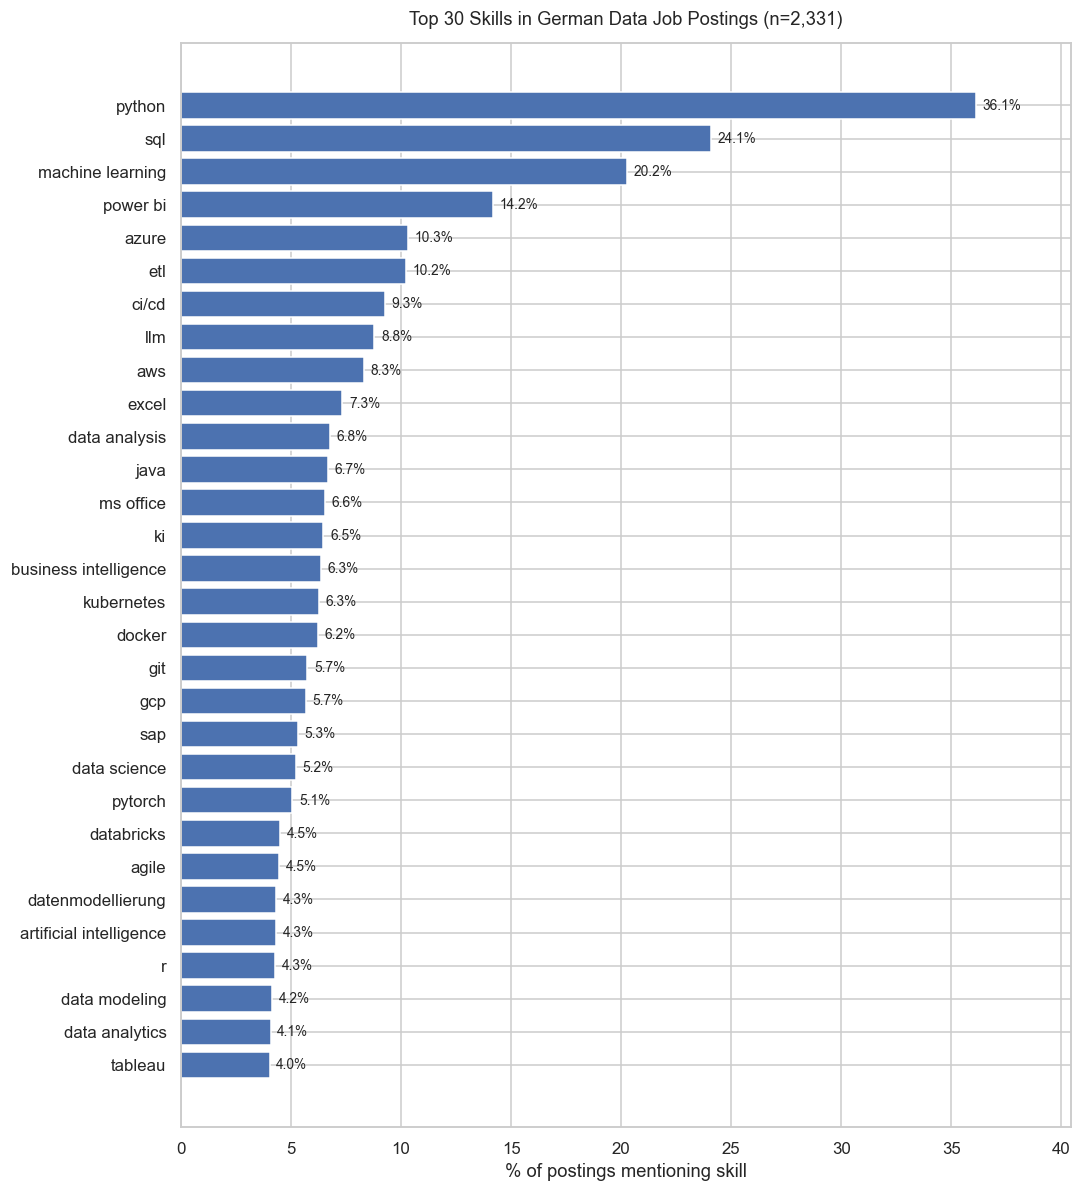

In [5]:
fig, ax = plt.subplots(figsize=(10, 11))
top_30_sorted = top_30.sort_values("pct_of_jobs", ascending=True)

bars = ax.barh(top_30_sorted["skill"], top_30_sorted["pct_of_jobs"], color="#4C72B0")
ax.set_xlabel("% of postings mentioning skill")
ax.set_title(f"Top 30 Skills in German Data Job Postings (n={n_jobs:,})", pad=12)

#Annotation
for bar, pct in zip(bars, top_30_sorted["pct_of_jobs"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=9)

ax.set_xlim(0, top_30_sorted["pct_of_jobs"].max() * 1.12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_30_skills_overall.png")
plt.show()

**What to look for in the chart above:**

- The top 3 skills are appearing in 20%+ of postings. Python dominates at 36%, almost twice the rate of SQL at 24%.
- Azure (10.3%) is beating AWS (8.3%)
- "Dirty Data" Reality - since "ki" (6.5%) and "artificial intelligence" (4.3%) are the same things we have to merge them. Also "datenmodellierung" and "data modelling" total is 8.5%

## 4. Role Classification

Pattern matching job titles failed badly. Instead of using German employers titles ("Mitarbeiter Datenanalyse im Risikomanagement and etc) 
we use Bunderagentur's own Hauptberuf field.
The German market uses many job title variants. To compare skill demand across roles, we map raw titles to canonical buckets:

- **Data Scientist** — `Data Scientist`, `Datenwissenschaftler`, `Applied Scientist`, `Research Scientist`
- **Data Analyst** — `Data Analyst`, `Datenanalyst`, `Business Analyst`, `BI Analyst/Developer`
- **Data Engineer** — `Data Engineer`, `Analytics Engineer`, `Dateningenieur`
- **ML Engineer** — `Machine Learning Engineer`, `ML Engineer`, `MLOps Engineer`
- **AI Engineer** — `AI Engineer`, `Artificial Intelligence Engineer`
- **Other** — everything else (managerial, hybrid, ambiguous)

Pattern order matters: we check ML/AI/MLOps first, since "ML Engineer (Data Science background)" should map to MLE, not DS.

In [6]:
# BA's official hauptberuf classification, mapped to clean English buckets.
# Anything not in this map gets dropped from role analysis (treated as non-data noise).
HAUPTBERUF_TO_ROLE = {
    "Data Scientist": "Data Scientist",
    "Datenwissenschaftler/in": "Data Scientist",
    "Wissenschaftliche/r Mitarbeiter/in": "Data Scientist",  # research-flavored

    "Data-Analyst/in": "Data Analyst",
    "Business-Analyst/in": "Data Analyst",
    "Data-Warehouse-Analyst/in": "Data Analyst",
    
    "Data Engineer": "Data Engineer",
    "Datenbankentwickler/in": "Data Engineer",
    "Cloud-Architect": "Data Engineer",   # cloud/platform infra
    
    "Machine Learning Engineer": "ML Engineer",
    "KI-Engineer": "ML Engineer",
    
    "Business-Intelligence-Consultant": "BI / Analytics",
    "Controller/in": "BI / Analytics",  # mostly reporting/analytics roles in this dataset
    
    "DevOps Engineer": "MLOps / DevOps",

    "Produktmanager/in": "Data Product",
    "Application-Engineer/-Manager/in": "Data Product",
}

#Mapping
df["role"] = df["hauptberuf"].map(HAUPTBERUF_TO_ROLE)
df["role"] = df["role"].fillna("Not a core data role")

role_counts = df["role"].value_counts()
print(role_counts)
print(f"\nCore data roles classified: {(df['role'] != 'Not a core data role').sum():,} / {len(df):,} ({(df['role'] != 'Not a core data role').mean()*100:.1f}%)")

role
Not a core data role    1417
Data Engineer            252
Data Analyst             232
Data Scientist           157
BI / Analytics           116
ML Engineer               96
Data Product              41
MLOps / DevOps            20
Name: count, dtype: int64

Core data roles classified: 914 / 2,331 (39.2%)


In [7]:
NOISE_PATTERNS = re.compile(
    r"^("
    r"controller|business controller|"
    r"electrical engineer|simulation engineer|digital design engineer|"
    r"fullstack|frontend|backend|"
    r"praktikum entrepreneur|"
    r"unknown|"
    r"ausbildung (?!.*(data|analytics|ki|ai))|"  # apprenticeships unless data-related
    r"duales studium (?!.*(data|analytics|ki|ai))"
    r")",
    re.I,
)

df["is_noise"] = df["clean_title"].fillna("").str.match(NOISE_PATTERNS)
noise_count = df["is_noise"].sum()
print(f"Filtering {noise_count} non-data postings as scraper noise")

Filtering 95 non-data postings as scraper noise


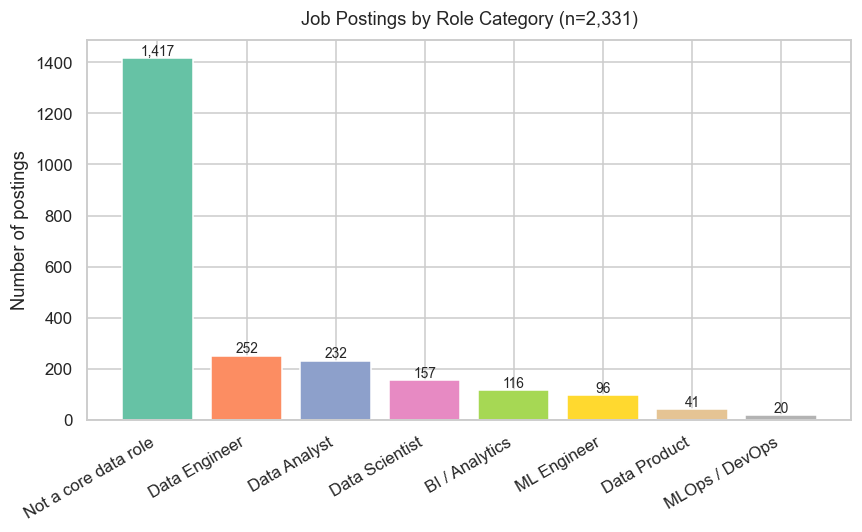

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("Set2", len(role_counts))
bars = ax.bar(role_counts.index, role_counts.values, color=colors)
ax.set_ylabel("Number of postings")
ax.set_title(f"Job Postings by Role Category (n={len(df):,})", pad=10)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, role_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{count:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "role_distribution.png")
plt.show()

## 5. Top Skills by Role

Now we slice the top skills by role. The interesting question: **which skills are universal vs role-specific?**

- Python is universal (~50%+ for DS/MLE) but drops to 9% for BI/Analytics
- SQL is more evenly across roles (15-37%) than Python
- Spark/Airflow/Docker skew toward Data Engineer / ML Engineer (engineering-flavored)
- Power BI / Tableau / Excel skew toward Data Analyst / BI (visualization-flavored)
- PyTorch / TensorFlow / scikit-learn skew toward Data Scientist / ML Engineer

In [9]:
target_roles = ["Data Scientist", "Data Analyst", "Data Engineer", "ML Engineer", "BI / Analytics"]
df_roles = df[df["role"].isin(target_roles)].copy()
print(f"Roles being compared: {target_roles}")
print(f"Total postings in this slice: {len(df_roles):,}")
print(df_roles["role"].value_counts())

Roles being compared: ['Data Scientist', 'Data Analyst', 'Data Engineer', 'ML Engineer', 'BI / Analytics']
Total postings in this slice: 853
role
Data Engineer     252
Data Analyst      232
Data Scientist    157
BI / Analytics    116
ML Engineer        96
Name: count, dtype: int64


In [10]:
TOP_N_SKILLS = 25

top_skills_global = [s for s, _ in skill_counts.most_common(TOP_N_SKILLS)]

heatmap_data = []
for role in target_roles:
    role_df = df_roles[df_roles["role"] == role]
    role_n = len(role_df)
    if role_n == 0:
        continue
    role_skill_counts = Counter(s for skills in role_df["all_skills_norm"] for s in skills)
    for skill in top_skills_global:
        pct = 100 * role_skill_counts.get(skill, 0) / role_n
        heatmap_data.append({"skill": skill, "role": role, "pct": pct, "n_role": role_n})

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_pivot = heatmap_df.pivot(index="skill", columns="role", values="pct")
heatmap_pivot = heatmap_pivot.reindex(top_skills_global) 
heatmap_pivot.head()

role,BI / Analytics,Data Analyst,Data Engineer,Data Scientist,ML Engineer
skill,,,,,
python,9.482759,30.603448,53.174603,62.420382,60.416667
sql,29.310345,37.500000,51.190476,36.305732,14.583333
machine learning,3.448276,9.051724,11.111111,35.031847,40.625000
power bi,31.896552,33.189655,13.095238,13.375796,3.125000
azure,5.172414,9.482759,25.396825,12.101911,11.458333


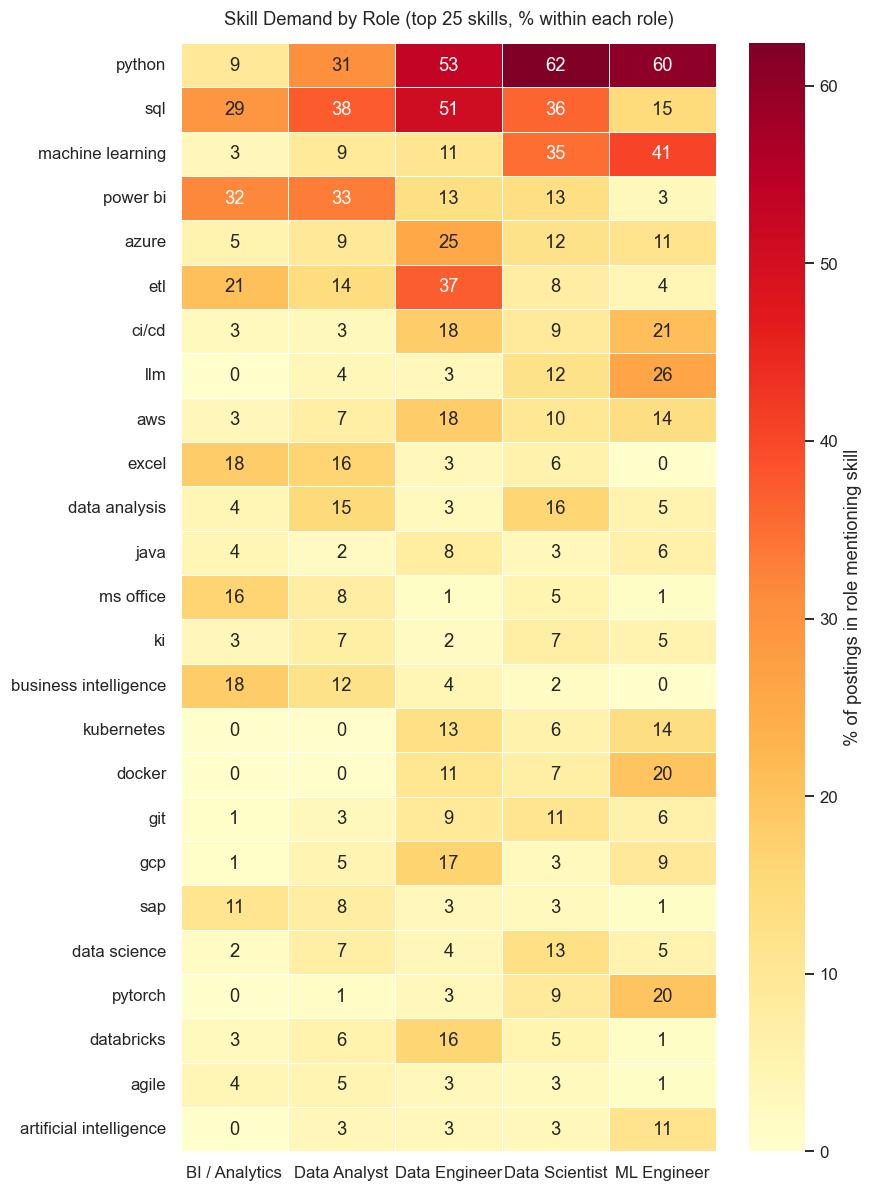

In [11]:
fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "% of postings in role mentioning skill"},
    linewidths=0.5,
    ax=ax,
)
ax.set_title(f"Skill Demand by Role (top {TOP_N_SKILLS} skills, % within each role)", pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "skills_by_role_heatmap.png")
plt.show()

**Reading the heatmap:**

- Dark cells = skill is heavily demanded for that role
- Python is dark across nearly all columns = universal skill (dropped in BI/Analytics)
- A row dark in one column only = role-specific skill (e.g. ETL for Data Engineer or LLM, Pytorch, Docker for ML Engineer)

## 6. Required vs Nice-to-Have

For each top skill, we compare how often it appears in the "required" section vs the "nice-to-have" section.

**What this reveals:** which skills are gate-keeping (you need them to pass screening) vs which are bonus points.

Interpretation guide:
- Skills with high required-share are *table stakes* (e.g. Python, SQL)
- Skills with high nice-to-have-share are *plus points* — worth learning but not blocking (e.g. specific tools, certifications)
- Big required-share + big nice-to-have-share = the skill is ubiquitous but companies disagree on whether it's mandatory

In [12]:
TOP_N = 25
req_counts = Counter(s for skills in df["required_skills_norm"] for s in skills)
nth_counts = Counter(s for skills in df["nice_to_have_skills_norm"] for s in skills)

comparison_rows = []
for skill, _ in skill_counts.most_common(TOP_N):
    req = req_counts.get(skill, 0)
    nth = nth_counts.get(skill, 0)
    total_mentions = req + nth
    if total_mentions == 0:
        continue
    comparison_rows.append({
        "skill": skill,
        "required_count": req,
        "nice_to_have_count": nth,
        "total_count": total_mentions,
        "pct_required": 100 * req / total_mentions if total_mentions else 0,
        "pct_nice_to_have": 100 * nth / total_mentions if total_mentions else 0,
    })

req_nth_df = pd.DataFrame(comparison_rows).sort_values("total_count", ascending=True)
req_nth_df

,skill,required_count,nice_to_have_count,total_count,pct_required,pct_nice_to_have
24,artificial intelligence,86,15,101,85.148515,14.851485
23,agile,89,15,104,85.576923,14.423077
22,databricks,86,19,105,81.904762,18.095238
21,pytorch,103,15,118,87.288136,12.711864
20,data science,103,19,122,84.426230,15.573770
19,sap,102,22,124,82.258065,17.741935
17,git,114,20,134,85.074627,14.925373
18,gcp,117,27,144,81.250000,18.750000
16,docker,123,22,145,84.827586,15.172414
15,kubernetes,125,21,146,85.616438,14.383562


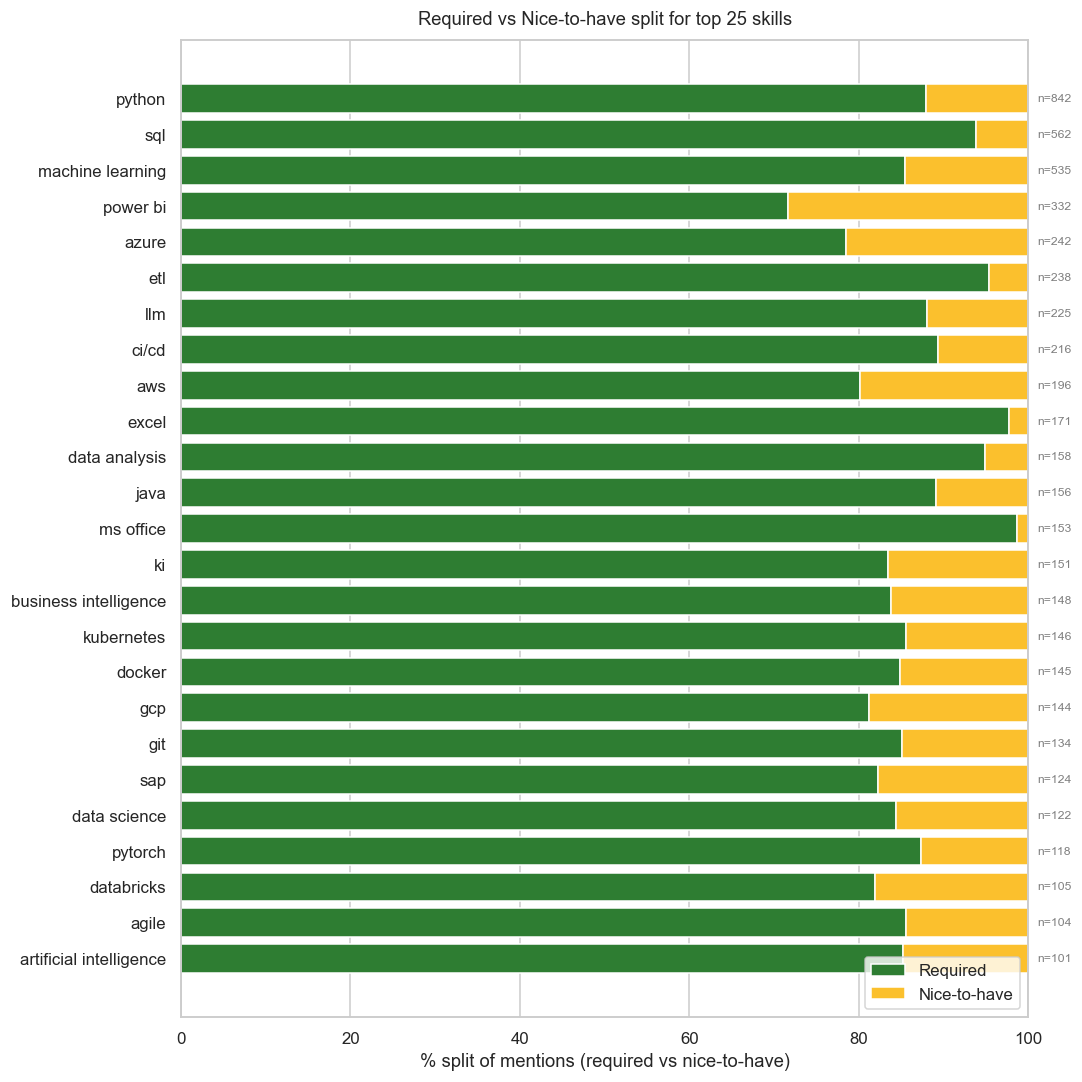

In [13]:
# Stacked horizontal bar: required (green) vs nice-to-have (yellow) for top skills
fig, ax = plt.subplots(figsize=(10, 10))

skills = req_nth_df["skill"]
req_pct = req_nth_df["pct_required"]
nth_pct = req_nth_df["pct_nice_to_have"]

ax.barh(skills, req_pct, color="#2E7D32", label="Required")
ax.barh(skills, nth_pct, left=req_pct, color="#FBC02D", label="Nice-to-have")

ax.set_xlabel("% split of mentions (required vs nice-to-have)")
ax.set_title(f"Required vs Nice-to-have split for top {TOP_N} skills", pad=10)
ax.set_xlim(0, 100)
ax.legend(loc="lower right")

# Annotate with total mention count on the right of each bar
for i, (skill, total) in enumerate(zip(skills, req_nth_df["total_count"])):
    ax.text(101, i, f"n={total}", va="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "required_vs_nice_to_have.png")
plt.show()

## 7. Skill Co-occurrence

Which skills appear *together* in postings? This reveals the "bundles" employers think of as a coherent skill set.

We compute the **Jaccard similarity** for each pair of top skills:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

where $|A \cap B|$ = number of jobs mentioning both, and $|A \cup B|$ = number of jobs mentioning either.

Jaccard handles imbalanced skills better than raw co-occurrence counts — a high score means the skills cluster together.

In [14]:
TOP_N_COOC = 20
top_cooc_skills = [s for s, _ in skill_counts.most_common(TOP_N_COOC)] 

# Convert each job's skill list to a set for efficient intersection
job_skill_sets = [set(skills) for skills in df["all_skills_norm"]]

# Jaccard matrix
jaccard_matrix = pd.DataFrame(
    np.zeros((TOP_N_COOC, TOP_N_COOC)),
    index=top_cooc_skills,
    columns=top_cooc_skills,
)

for skill_a, skill_b in combinations(top_cooc_skills, 2):
    jobs_with_a = sum(1 for s in job_skill_sets if skill_a in s)
    jobs_with_b = sum(1 for s in job_skill_sets if skill_b in s)
    jobs_with_both = sum(1 for s in job_skill_sets if skill_a in s and skill_b in s)
    union = jobs_with_a + jobs_with_b - jobs_with_both
    jaccard = jobs_with_both / union if union > 0 else 0
    jaccard_matrix.loc[skill_a, skill_b] = jaccard
    jaccard_matrix.loc[skill_b, skill_a] = jaccard

for s in top_cooc_skills:
    jaccard_matrix.loc[s, s] = 1.0

jaccard_matrix.round(2).head()

,python,sql,machine learning,power bi,azure,etl,ci/cd,llm,aws,excel,data analysis,java,ms office,ki,business intelligence,kubernetes,docker,git,gcp,sap
python,1.00,0.36,0.23,0.13,0.17,0.13,0.17,0.13,0.16,0.03,0.07,0.13,0.03,0.05,0.02,0.12,0.13,0.12,0.11,0.03
sql,0.36,1.00,0.10,0.26,0.17,0.26,0.12,0.06,0.15,0.06,0.07,0.10,0.03,0.03,0.06,0.06,0.07,0.10,0.09,0.05
machine learning,0.23,0.10,1.00,0.04,0.08,0.03,0.07,0.13,0.08,0.01,0.08,0.05,0.02,0.16,0.02,0.05,0.07,0.05,0.06,0.01
power bi,0.13,0.26,0.04,1.00,0.09,0.12,0.03,0.02,0.06,0.16,0.10,0.03,0.09,0.03,0.12,0.00,0.01,0.03,0.02,0.07
azure,0.17,0.17,0.08,0.09,1.00,0.15,0.17,0.09,0.41,0.01,0.02,0.10,0.00,0.03,0.03,0.14,0.15,0.08,0.27,0.03


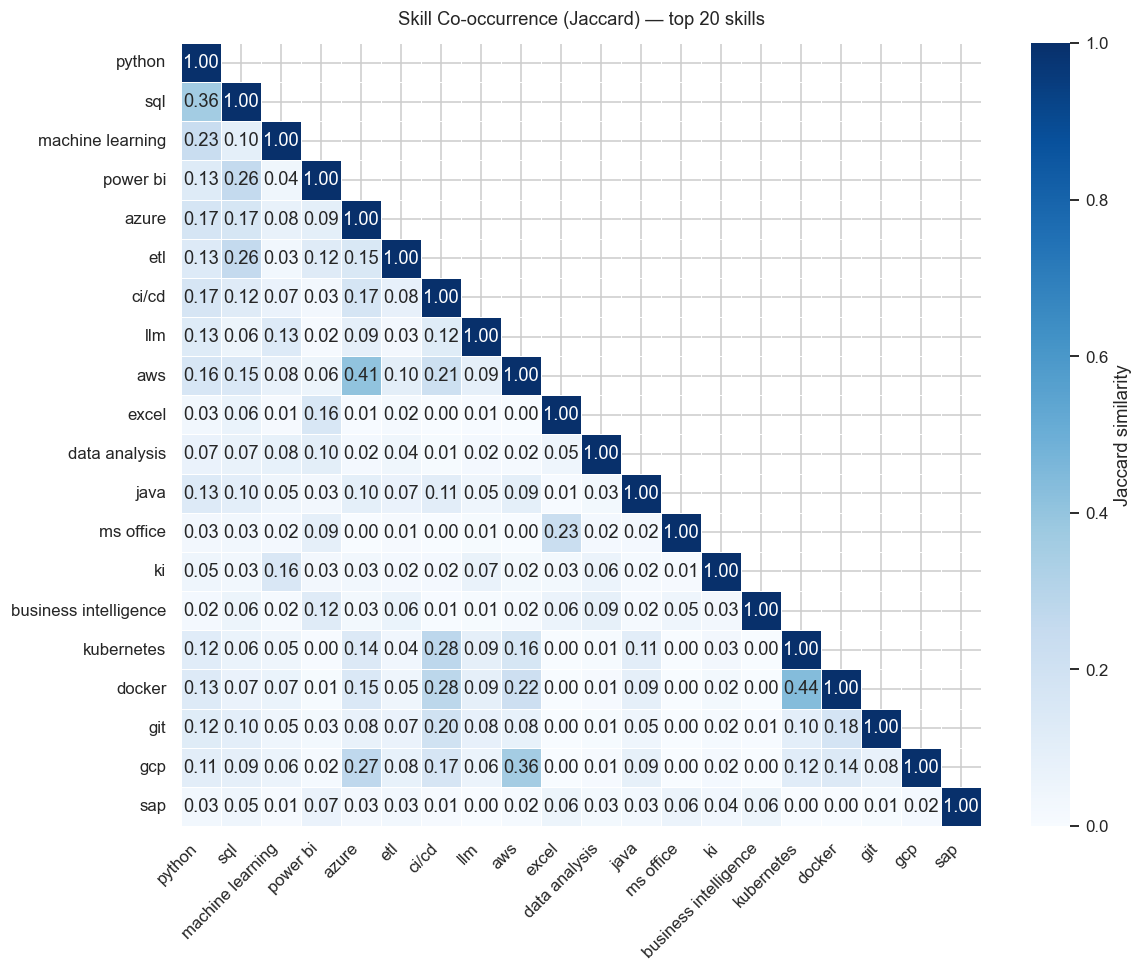

In [15]:
mask = np.triu(np.ones_like(jaccard_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    jaccard_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Jaccard similarity"},
    linewidths=0.5,
    vmin=0,
    vmax=jaccard_matrix.values[~mask].max() if not mask.all() else 1,
    ax=ax,
)
ax.set_title(f"Skill Co-occurrence (Jaccard) — top {TOP_N_COOC} skills", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "skill_cooccurrence.png")
plt.show()

In [16]:
# Surface the strongest co-occurring pairs as a table (more readable than the heatmap for the post)
pair_data = []
for skill_a, skill_b in combinations(top_cooc_skills, 2):
    score = jaccard_matrix.loc[skill_a, skill_b]
    if score > 0:
        pair_data.append({"skill_a": skill_a, "skill_b": skill_b, "jaccard": score})

top_pairs = pd.DataFrame(pair_data).sort_values("jaccard", ascending=False).head(15).reset_index(drop=True)
top_pairs.round(3)

,skill_a,skill_b,jaccard
0,kubernetes,docker,0.441
1,azure,aws,0.409
2,python,sql,0.362
3,aws,gcp,0.358
4,ci/cd,docker,0.285
5,ci/cd,kubernetes,0.279
6,azure,gcp,0.270
7,sql,power bi,0.257
8,sql,etl,0.256
9,python,machine learning,0.235


## 8. Key Findings

After running the cells above, write your bullet-point findings here. Format suggestion:

### Universal skills (table stakes)
- e.g. *"Python appears in ~37% of postings; SQL in 24%. Together they form the floor of the German data market"*

### Role-defining skills
- **Data Scientist:** scikit-learn / PyTorch / TensorFlow dominate; SQL still mandatory
- **Data Analyst:** Power BI / Tableau / Excel dominate; less programming-heavy
- **Data Engineer:** Spark / Airflow / Docker / cloud (AWS) dominate
- **ML Engineer:** intersection of DS skills + DE infrastructure

### Surprising findings
- e.g. **"R is still requested in 4.3% of postings — declining but not dead."**

### Required vs nice-to-have insights
- **Excel**: 167 required vs 4 nice-to-have (98% required). When employers ask for Excel, it's not optional.
- **MS Office**: 151 vs 2 (99%). Same pattern.
- **Data Analysis**: 150 vs 8 (95%).
### Skills with surprisingly high "nice-to have"
- **AWS**: 157 required + 39 nice-to-have. 20% of mentions are nice-to-have — meaningful given cloud's reputation as mandatory.
- **GCP**: 117 + 27 (19% nice-to-have). Same pattern, plus GCP is asked for less often overall than its market position suggests.
- **Databricks**: 86 + 19 (18% nice-to-have)

### Co-occurrence bundles
- **The strongest co-occuring bundle is the infrastructure/DevOps cluster (Kuberneter + Docker + CI/CD)**
- **Multi Cloud is also a stronger cluster - Azure + AWS and AWS +  GCP score above Python + SQL**
- **Additionally Pytorch and Tensorflow don't appear in top 15 pairs. That means companies pick one rather than ask for both**

